In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OrdinalEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("youtube_videos.csv")
df.head()

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,shares,watch_time_minutes,avg_view_duration_seconds,click_through_rate,channel_age_years,subscribers,tags_count,hashtags
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,1193,1091087,287,0.0100,1.3,441016,18.0,"[""ai"", ""tutorial"", ""trending""]"
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,183,423818,1014,0.0230,0.8,25339,17.0,"[""tutorial""]"
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,16119,12952634,587,0.1022,4.8,2398429,NaN,"[""explained""]"
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,1797,2018334,645,0.0413,3.9,498144,13.0,"[""gaming"", ""trending"", ""explained"", ""tech""]"
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,30,262565,1252,0.0100,1.3,30039,10.0,"[""explained"", ""shorts""]"


In [3]:
minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

In [4]:
df["subscribers_minmax"] = minmax_scaler.fit_transform(df[["subscribers"]])

In [5]:
df["subscribers_minmax"].describe()

count    210.000000
mean       0.128853
std        0.265999
min        0.000000
25%        0.002555
50%        0.016794
75%        0.061946
max        1.000000
Name: subscribers_minmax, dtype: float64

In [6]:
df["views_zscore"] = standard_scaler.fit_transform(df[["views"]])
df[["views", "views_zscore"]].describe()


,views,views_zscore
count,2.100000e+02,2.100000e+02
mean,5.485440e+05,2.537653e-17
std,1.223751e+06,1.002389e+00
min,1.412000e+03,-4.481625e-01
25%,1.080400e+04,-4.404694e-01
50%,6.597350e+04,-3.952794e-01
75%,3.108772e+05,-1.946757e-01
max,7.038551e+06,5.316044e+00


In [51]:
df["shares_minmax"] = minmax_scaler.fit_transform(df[["shares"]])
df["shares_zscore"] = standard_scaler.fit_transform(df[["shares"]])
df["shares_robust"] = robust_scaler.fit_transform(df[["shares"]])
df[["shares", "shares_minmax", "shares_zscore", "shares_robust"]].describe()

,shares,shares_minmax,shares_zscore,shares_robust
count,210.000000,210.000000,210.000000,210.000000
mean,3947.052381,0.082128,0.000000,1.658617
std,8731.782974,0.181916,1.002389,4.009543
min,5.000000,0.000000,-0.452539,-0.151533
25%,65.500000,0.001260,-0.445594,-0.123752
50%,335.000000,0.006875,-0.414656,0.000000
75%,2243.250000,0.046631,-0.195593,0.876248
max,48004.000000,1.000000,5.057641,21.889106


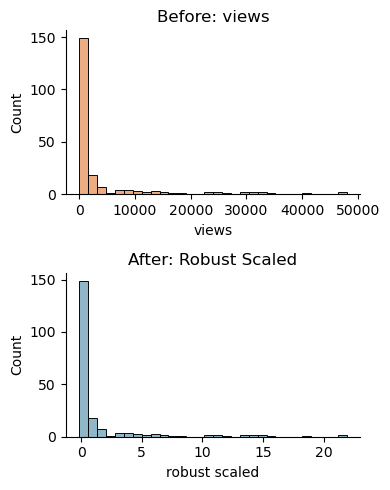

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["shares"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: views")
axes[0].set_xlabel("views")

sns.histplot(df["shares_robust"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: Robust Scaled")
axes[1].set_xlabel("robust scaled")

sns.despine()
plt.tight_layout()
plt.show()

In [9]:
df["views_log"] = np.log1p(df["views"])

<Axes: xlabel='views_log', ylabel='Count'>

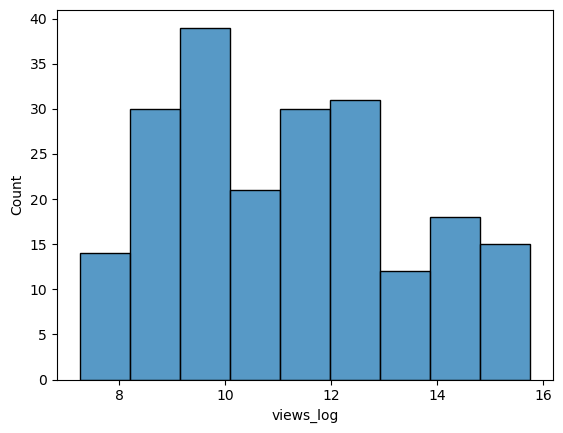

In [10]:
sns.histplot(df["views_log"])

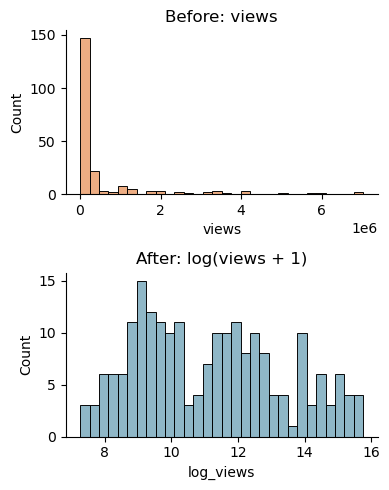

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["views"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: views")
axes[0].set_xlabel("views")

sns.histplot(df["views_log"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: log(views + 1)")
axes[1].set_xlabel("log_views")

sns.despine()
plt.tight_layout()
plt.show()

In [12]:
bins = [0, 300, 2000, float("inf")]
labels = ["short", "medium", "long"]

df["duration_bin"] = pd.cut(df["duration_seconds"], bins=bins, labels=labels)

In [13]:
df["shares"].describe()

count      210.000000
mean      3947.052381
std       8731.782974
min          5.000000
25%         65.500000
50%        335.000000
75%       2243.250000
max      48004.000000
Name: shares, dtype: float64

In [14]:
bins = [0, 500, 3000, float("inf")]
labels = ["Unknown", "Normal", "Trending"]

df["shares_bin"] = pd.cut(df["shares"], bins=bins, labels=labels)

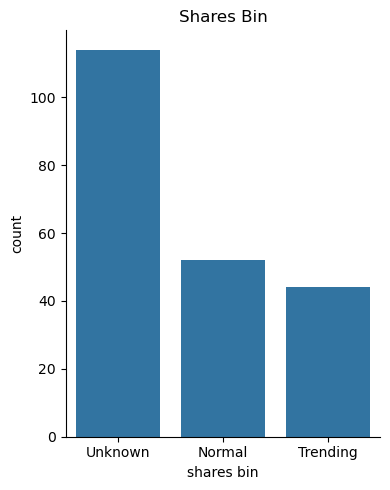

In [15]:
fig, ax = plt.subplots(figsize=(4, 5))
colors = ["#6a9fb5", "#e8925a", "#7a7a7a"]

sns.countplot(data=df,
              x="shares_bin",
              ax=ax)
ax.set_title("Shares Bin")
ax.set_xlabel("shares bin")
ax.set_ylabel("count")

sns.despine()
plt.tight_layout()
plt.show()

In [16]:
df["channel_tier"].unique()

array(['Mid', 'Small', 'Large'], dtype=object)

In [17]:
encoder = OrdinalEncoder(categories=[['Mid', 'Small', 'Large']])
df[["channel_tier_encoded"]] = encoder.fit_transform(df[["channel_tier"]]).astype(int)
df[["channel_tier_encoded"]]

,channel_tier_encoded
0,0
1,1
2,2
3,0
4,1
...,...
205,1
206,1
207,0
208,1


In [18]:
dummyVars = pd.get_dummies(df["category"], prefix="is")
dummyVars

,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,False,False,False,True,False,False
1,False,False,True,False,False,False
2,False,False,True,False,False,False
3,False,False,True,False,False,False
4,False,False,False,True,False,False
...,...,...,...,...,...,...
205,False,True,False,False,False,False
206,False,False,False,False,True,False
207,False,False,True,False,False,False
208,True,False,False,False,False,False


In [19]:
df = pd.concat([df, dummyVars], axis=1)
df.head()

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,...,views_log,duration_bin,shares_bin,channel_tier_encoded,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,...,12.337553,medium,Normal,0,False,False,False,True,False,False
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,...,10.129786,medium,Unknown,1,False,False,True,False,False,False
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,...,14.096130,medium,Trending,2,False,False,True,False,False,False
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,...,12.142883,medium,Normal,0,False,False,True,False,False,False
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,...,9.440181,long,Unknown,1,False,False,False,True,False,False


In [20]:
df["caps_count"] = df["title"].apply(
    lambda t: sum(1 for w in t.split() if w.isupper())
)
df["caps_count"]

0      3
1      1
2      0
3      0
4      4
      ..
205    3
206    2
207    0
208    2
209    3
Name: caps_count, Length: 210, dtype: int64

In [21]:

from sklearn.feature_extraction.text import TfidfVectorizer

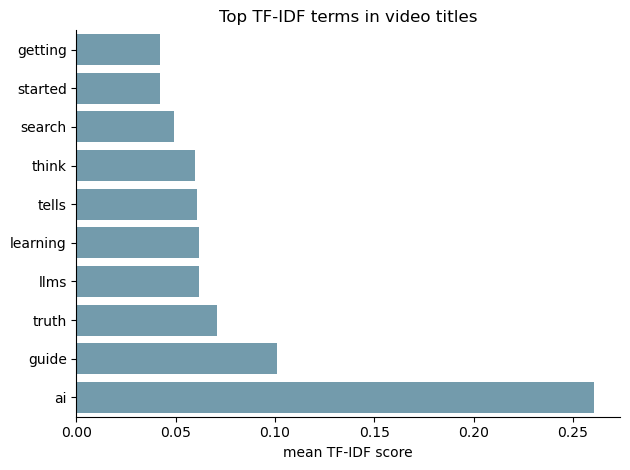

In [22]:
vectorizer = TfidfVectorizer(max_features=10, stop_words="english")
tfidf_matrix = vectorizer.fit_transform(df["title"])

terms = vectorizer.get_feature_names_out()
mean_scores = tfidf_matrix.toarray().mean(axis=0)

tfidf_df = pd.DataFrame({
    "term": terms,
    "mean_tfidf": mean_scores
}).sort_values("mean_tfidf", ascending=True)

sns.barplot(data=tfidf_df,
            x="mean_tfidf",
            y="term",
            color="#6a9fb5")

plt.title("Top TF-IDF terms in video titles")
plt.xlabel("mean TF-IDF score")
plt.ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

In [23]:
df["duration_minutes"] = df["duration_seconds"] / 60
df["retention_rate"] = df["watch_time_minutes"] / (df["views"] * df["duration_minutes"])

In [24]:
df["retention_rate"]

0      0.398058
1      0.535375
2      0.415428
3      0.483146
4      0.396453
         ...   
205    0.469772
206    0.289126
207    0.495605
208    0.528993
209    0.434620
Name: retention_rate, Length: 210, dtype: float64

In [49]:
df["hashtags"] = df["hashtags"].apply(json.loads)

from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
hashtag_encoded = pd.DataFrame(
    mlb.fit_transform(df["hashtags"]),
    columns=mlb.classes_,
    index=df.index
)

result = pd.concat([df[["video_id"]], hashtag_encoded], axis=1)
print(result.head(4).to_string(index=False))

video_id  ai  chatgpt  comedy  datascience  deeplearning  explained  gaming  howto  llm  machinelearning  music  news  python  review  shorts  tech  trending  tutorial  viral  vlog
vid_0000   1        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         1         1      0     0
vid_0001   0        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         0         1      0     0
vid_0002   0        0       0            0             0          1       0      0    0                0      0     0       0       0       0     0         0         0      0     0
vid_0003   0        0       0            0             0          1       1      0    0                0      0     0       0       0       0     1         1         0      0     0
